In [3]:
import os

import anndata
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from Bio import Phylo
import scgenome.plotting as pl

from cellmates.common_helpers.cnasim_data import profiles_to_anndata


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# DICE benchmark data visualization
Visualize CNAsim datasets downloaded from: [zenodo link](https://zenodo.org/records/10108731)

## Defaults parameters
Each dataset shows variations of one or more parameters, all the rest are fixed to defaults parameters. Below is the list of parameters defaults:
```
defaults:
  n_cells: 250
  n_chromosomes: 22
  chromosome_length: 100
  mean_cnas_per_edge: 2
  bin_size: 1000000
  n_clones: 0
  wgd: false
  boundary_noise: 0
  jitter: 0
```

In [1]:
dat_path = "/home/vittorio.zampinetti/data/cnasim_simulated_datasets/CNAsim"

## A datasets

| Dataset | Number of cells |
|---------|-----------------|
| A1      | 10              |
| A2      | 25              |
| A3      | 50              |
| A4      | 75              |
| A5      | 100             |
| A6      | 250             |
| A7      | 500             |

In [5]:
test_dat = os.path.join(dat_path, "A2_1", "1")
tree_nwk_path = os.path.join(test_dat, "tree.nwk")
test_tree_bio = Phylo.read(tree_nwk_path,'newick')
test_adata = profiles_to_anndata(os.path.join(test_dat, 'profiles.tsv'))
test_adata

AnnData object with n_obs × n_vars = 25 × 2875
    var: 'chr', 'start', 'end'

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


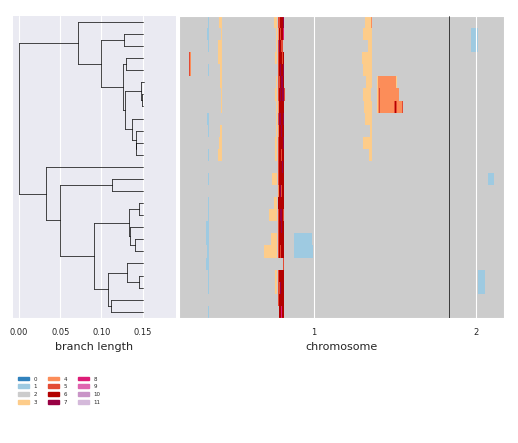

In [9]:
g = pl.plot_cell_cn_matrix_fig(test_adata[:, :300], layer_name=None, tree=test_tree_bio)

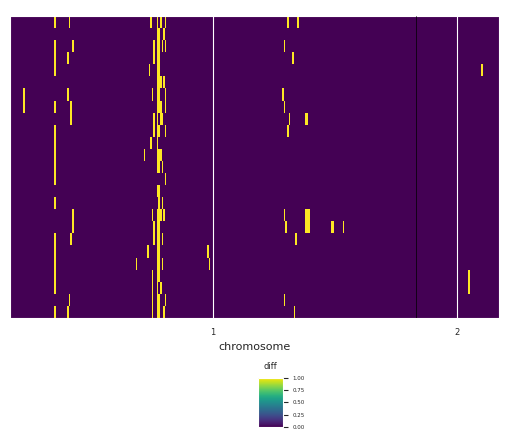

In [10]:
# breakpoint checks
test_adata.layers['diff'] = np.diff(test_adata.X, append=0) > 0
g = pl.plot_cell_cn_matrix_fig(test_adata[:, :300], layer_name='diff', raw=True)
